# Insurance Claims Analysis

## Project Overview

This project analyzes an insurance claims dataset to identify factors
associated with claim status and evaluate predictive models for claim
risk.

The analysis includes exploratory data analysis, statistical testing,
logistic regression, odds-ratio interpretation, random forest comparison,
and out-of-sample model evaluation.

## 1. Import Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Inspect Data

In [55]:
df = pd.read_csv("/Users/phoeberife/insurance-claims-analysis/data/Insurance-claims-data.csv")

In [56]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [57]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age',
       'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'steering_type', 'turning_radius', 'length',
       'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status'],
      dtype='str')

In [58]:
df.dtypes

policy_id                               str
subscription_length                 float64
vehicle_age                         float64
customer_age                          int64
region_code                             str
region_density                        int64
segment                                 str
model                                   str
fuel_type                               str
max_torque                              str
max_power                               str
engine_type                             str
airbags                               int64
is_esc                                  str
is_adjustable_steering                  str
is_tpms                                 str
is_parking_sensors                      str
is_parking_camera                       str
rear_brakes_type                        str
displacement                          int64
cylinder                              int64
transmission_type                       str
steering_type                   

In [ ]:
df.isnull().sum()

In [60]:
df["claim_status"].value_counts()

claim_status
0    54844
1     3748
Name: count, dtype: int64

6.4 percent of policy holders filed claims

In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
subscription_length,58592.0,6.111688,4.142790,0.0,2.1,5.7,10.4,14.0
vehicle_age,58592.0,1.388473,1.134413,0.0,0.4,1.2,2.2,20.0
customer_age,58592.0,44.823935,6.935604,35.0,39.0,44.0,49.0,75.0
region_density,58592.0,18826.858667,17660.174792,290.0,6112.0,8794.0,27003.0,73430.0
airbags,58592.0,3.137066,1.832641,1.0,2.0,2.0,6.0,6.0
displacement,58592.0,1162.355851,266.304786,796.0,796.0,1197.0,1493.0,1498.0
cylinder,58592.0,3.626963,0.483616,3.0,3.0,4.0,4.0,4.0
turning_radius,58592.0,4.852893,0.228061,4.5,4.6,4.8,5.0,5.2
length,58592.0,3850.476891,311.457119,3445.0,3445.0,3845.0,3995.0,4300.0
width,58592.0,1672.233667,112.089135,1475.0,1515.0,1735.0,1755.0,1811.0


## 3. EDA 

## The first stage of the analysis examines the distribution of key variables and the overall claim rate. This helps identify potential relationships that can be investigated more formally later on.

## fuel type

In [63]:
df["fuel_type"].value_counts()

fuel_type
Petrol    20532
CNG       20330
Diesel    17730
Name: count, dtype: int64

In [64]:
pd.crosstab(
    df["fuel_type"],
    df["claim_status"],
    normalize="index"
) * 100

claim_status,0,1
fuel_type,,
CNG,93.925234,6.074766
Diesel,93.513818,6.486182
Petrol,93.361582,6.638418


In [65]:
claim_rate_by_fuel = (
    df.groupby("fuel_type")["claim_status"]
      .mean() * 100
)

claim_rate_by_fuel

fuel_type
CNG       6.074766
Diesel    6.486182
Petrol    6.638418
Name: claim_status, dtype: float64

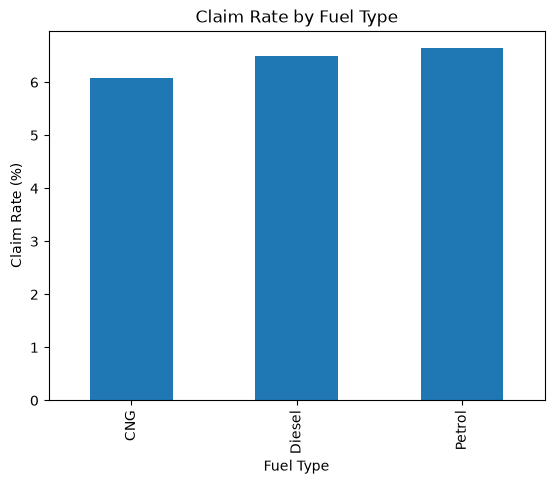

In [67]:
claim_rate_by_fuel.plot(
    kind="bar",
    title="Claim Rate by Fuel Type",
    ylabel="Claim Rate (%)",
    xlabel="Fuel Type"
)

plt.show()

## Highest observed claim rate associated with policies that have Petrol fuel (35% of all policies/highest proportion of all fuel types) 

## Customer age

In [68]:
df["customer_age"].describe()

count    58592.000000
mean        44.823935
std          6.935604
min         35.000000
25%         39.000000
50%         44.000000
75%         49.000000
max         75.000000
Name: customer_age, dtype: float64

In [69]:
df["customer_age"].value_counts().sort_index()

customer_age
35    2949
36    3183
37    3343
38    1733
39    3490
40    5116
41    3360
42    1613
43    3387
44    3284
45    3364
46    1563
47    3087
48    2779
49    2500
50    2164
51     927
52    1720
53    1438
54    1887
55     560
56     976
57     879
58     819
59     345
60     620
61     520
62     371
63     131
64     202
65     115
66      69
67      21
68      36
69      17
70       8
71       3
72       7
73       3
74       2
75       1
Name: count, dtype: int64

In [70]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[34, 44, 54, 64, 75],
    labels=["35-44", "45-54", "55-64", "65+"]
)

In [71]:
df["age_group"].value_counts().sort_index()

age_group
35-44    31458
45-54    21429
55-64     5423
65+        282
Name: count, dtype: int64

In [72]:
claim_rate_by_age = (
    df.groupby("age_group", observed=True)["claim_status"]
      .mean() * 100
)

print(claim_rate_by_age)

age_group
35-44     6.008011
45-54     6.663867
55-64     7.246911
65+      13.120567
Name: claim_status, dtype: float64


In [73]:
age_claim_analysis = (
    df.groupby("age_group", observed=True)
      .agg(
          observations=("claim_status", "size"),
          claims=("claim_status", "sum"),
          claim_rate=("claim_status", "mean")
      )
)

age_claim_analysis["claim_rate"] *= 100

age_claim_analysis

,observations,claims,claim_rate
age_group,,,
35-44,31458,1890,6.008011
45-54,21429,1428,6.663867
55-64,5423,393,7.246911
65+,282,37,13.120567


## Positive relationship between age group and estimated claim rates, but a negative relationship between age group and number of observations. eg. claim rate of 13.12% among customers aged 65+, which is ~7 percent higher than ages 35-44 but  the 65+ group contains 31,176 fewer obserations, only 282, so its estimate is less precise.

In [156]:
df["vehicle_age_group"] = pd.cut(
    df["vehicle_age"],
    bins=[-0.01, 1, 3, 5, float("inf")],
    labels=["0-1", "1-3", "3-5", "5+"]
)

In [157]:
df["vehicle_age_group"].value_counts().sort_index()

vehicle_age_group
0-1    28328
1-3    25815
3-5     4226
5+       223
Name: count, dtype: int64

In [158]:
vehicle_age_analysis = (
    df.groupby("vehicle_age_group", observed=True)
      .agg(
          observations=("claim_status", "size"),
          claims=("claim_status", "sum"),
          claim_rate=("claim_status", "mean")
      )
)

vehicle_age_analysis["claim_rate"] *= 100

vehicle_age_analysis

,observations,claims,claim_rate
vehicle_age_group,,,
0-1,28328,1913,6.753036
1-3,25815,1638,6.345148
3-5,4226,190,4.495977
5+,223,7,3.139013


## Claim rates generally decreased across the vehicle-age groups, from 6.75% for vehicles aged 0–1 years to 3.14% for vehicles aged 5+ years. The 5+ group contains only 223 observations, including 7 claims, so the estimate should be interpreted cautiously.

In [74]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


## Quantify uncertainities

In [75]:
from statsmodels.stats.proportion import proportion_confint

In [76]:
age_claim_analysis["lower"] = [
    proportion_confint(claims, observations, method="wilson")[0] * 100
    for claims, observations in zip(
        age_claim_analysis["claims"],
        age_claim_analysis["observations"]
    )
]

age_claim_analysis["upper"] = [
    proportion_confint(claims, observations, method="wilson")[1] * 100
    for claims, observations in zip(
        age_claim_analysis["claims"],
        age_claim_analysis["observations"]
    )
]

age_claim_analysis

,observations,claims,claim_rate,lower,upper
age_group,,,,,
35-44,31458,1890,6.008011,5.750744,6.276020
45-54,21429,1428,6.663867,6.337659,7.005609
55-64,5423,393,7.246911,6.586724,7.967625
65+,282,37,13.120567,9.670944,17.561445


In [78]:
from scipy.stats import chi2_contingency

In [79]:
age_claim_table = pd.crosstab(
    df["age_group"],
    df["claim_status"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    age_claim_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 38.331969284268915
p-value: 2.404117664739314e-08
Degrees of freedom: 3


## Evidence that customer age was significantly associated with claim status. 

In [81]:
df["region_density"].describe()

count    58592.000000
mean     18826.858667
std      17660.174792
min        290.000000
25%       6112.000000
50%       8794.000000
75%      27003.000000
max      73430.000000
Name: region_density, dtype: float64

In [82]:
df["region_density"].quantile([0, .25, .5, .75, .9, .95, .99, 1])

0.00      290.0
0.25     6112.0
0.50     8794.0
0.75    27003.0
0.90    34738.0
0.95    73430.0
0.99    73430.0
1.00    73430.0
Name: region_density, dtype: float64

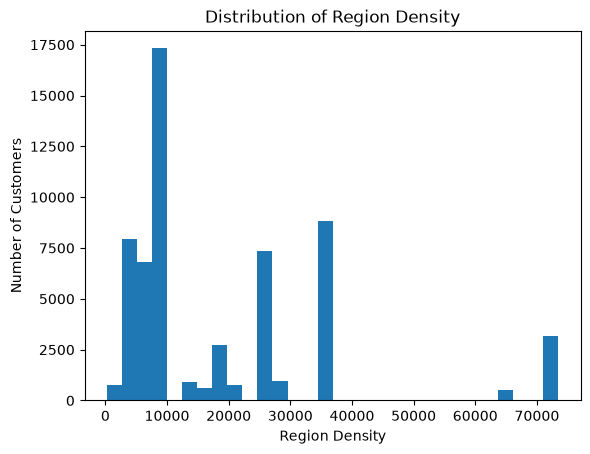

In [83]:
df["region_density"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Region Density",
    xlabel="Region Density",
    ylabel="Number of Customers"
)

plt.show()

In [84]:
df["region_density"].nunique()

22

In [85]:
df["region_density"].value_counts().head(20)

region_density
8794     13654
27003     7342
34738     6979
4076      6101
7788      3660
5410      3423
73430     3155
17804     2734
6112      2167
34791     1589
4990      1468
6108      1212
27742      952
13051      890
290        771
21622      665
65567      492
16206      401
3264       379
35036      242
Name: count, dtype: int64

In [86]:
df["region_density"].value_counts().sort_index()

region_density
290        771
3264       379
4076      6101
4990      1468
5410      3423
6108      1212
6112      2167
7788      3660
8794     13654
13051      890
16206      401
16733      207
17804     2734
20905      109
21622      665
27003     7342
27742      952
34738     6979
34791     1589
35036      242
65567      492
73430     3155
Name: count, dtype: int64

In [87]:
region_claim_analysis = (
    df.groupby("region_density")
      .agg(
          observations=("claim_status", "size"),
          claims=("claim_status", "sum"),
          claim_rate=("claim_status", "mean")
      )
)

region_claim_analysis["claim_rate"] *= 100

region_claim_analysis

,observations,claims,claim_rate
region_density,,,
290,771,38,4.928664
3264,379,29,7.651715
4076,6101,433,7.097197
4990,1468,76,5.177112
5410,3423,195,5.696757
6108,1212,72,5.940594
6112,2167,109,5.029995
7788,3660,281,7.677596
8794,13654,954,6.986964


## Statistical tests

In [88]:
region_claim_table = pd.crosstab(
    df["region_density"],
    df["claim_status"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    region_claim_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 96.082640616059
p-value: 1.4125575115958093e-11
Degrees of freedom: 21


## no simple pattern in region density / claims, but evidence for an association. more variation in claim rates

## 4. Logistic regression model
## Used because claim status is a binary outcome /model can estimate the relationship between the explanatory variables and the probability of a claim.

In [89]:
import statsmodels.formula.api as smf

model = smf.logit(
    "claim_status ~ customer_age + vehicle_age + C(fuel_type) + C(region_density)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.236010
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           claim_status   No. Observations:                58592
Model:                          Logit   Df Residuals:                    58566
Method:                           MLE   Df Model:                           25
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                0.007313
Time:                        16:49:56   Log-Likelihood:                -13828.
converged:                       True   LL-Null:                       -13930.
Covariance Type:            nonrobust   LLR p-value:                 5.814e-30
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -3.3976      0.199    -17.032      0.000      

In [94]:
import numpy as np

np.exp(model.params["customer_age"])

np.float64(1.011624075730032)

every one year older a customer is corresponds to a 1.16 percent increase in chance of a claim (with all else constant)

In [95]:
np.exp(model.params["vehicle_age"])

np.float64(0.8613677517812591)

86.14 percent decrease in chance of a claim per one year elapse of vechile age.

## Odds ratios (interpreting model) 
The strongest continuous-variable associations in the model was vehicle age. These results represent statistical associations rather than causal effects.

In [97]:
odds_ratios = np.exp(model.params)

odds_ratios


Intercept                     0.033454
C(fuel_type)[T.Diesel]        1.179139
C(fuel_type)[T.Petrol]        1.204576
C(region_density)[T.3264]     1.628536
C(region_density)[T.4076]     1.461808
C(region_density)[T.4990]     1.032267
C(region_density)[T.5410]     1.187482
C(region_density)[T.6108]     1.187655
C(region_density)[T.6112]     1.034606
C(region_density)[T.7788]     1.591689
C(region_density)[T.8794]     1.462812
C(region_density)[T.13051]    1.246022
C(region_density)[T.16206]    1.171394
C(region_density)[T.16733]    1.735604
C(region_density)[T.17804]    0.995522
C(region_density)[T.20905]    0.927413
C(region_density)[T.21622]    1.612436
C(region_density)[T.27003]    1.474101
C(region_density)[T.27742]    1.523981
C(region_density)[T.34738]    1.163663
C(region_density)[T.34791]    1.134495
C(region_density)[T.35036]    2.304729
C(region_density)[T.65567]    0.767119
C(region_density)[T.73430]    0.941381
customer_age                  1.011624
vehicle_age              

A logistic regression model found statistically significant associations between claim status and customer age, vehicle age, fuel type, and region density. Holding other modeled variables constant, customer age was associated with higher claim odds, while vehicle age was associated with lower claim odds. Diesel and petrol vehicles had higher estimated claim odds than CNG vehicles. Region density showed significant differences for some categories relative to the reference region, but there was no simple monotonic relationship between density and claim odds.

Despite variables showing statistically significant associations with claim status, they have limited explanatory power when combined in this model- observe Low Pseudo R-squ. 

In [98]:
y_prob = model.predict(df)

In [101]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict(df)

auc = roc_auc_score(df["claim_status"], y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.5675047599840184


## Current model is only slightly better than a randomly distigushing from customers with and without claims.

## EDA part two, and model improvement
## We saw pseudo-R²: 0.0073 and Test/in-sample ROC-AUC about 0.568 at the stage of the first logistic model using vechile and customer age, and region density. Contiunie to find variables to find meaningful relationships with claim rates. 
## Adding subscription length gave pseudo-R² = 0.0199.

## Segment & engine type

In [104]:
df["segment"].value_counts()

segment
B2         18314
A          17321
C2         14018
B1          4173
C1          3557
Utility     1209
Name: count, dtype: int64

In [105]:
df.groupby("segment")["claim_status"].agg(["count", "mean"])

,count,mean
segment,,
A,17321,0.060389
B1,4173,0.058471
B2,18314,0.068581
C1,3557,0.064099
C2,14018,0.064275
Utility,1209,0.060380


In [106]:
df["segment"].value_counts()

segment
B2         18314
A          17321
C2         14018
B1          4173
C1          3557
Utility     1209
Name: count, dtype: int64

In [107]:
df.groupby("segment")["claim_status"].agg(["count", "mean"])

,count,mean
segment,,
A,17321,0.060389
B1,4173,0.058471
B2,18314,0.068581
C1,3557,0.064099
C2,14018,0.064275
Utility,1209,0.060380


In [108]:
df["engine_type"].value_counts()

engine_type
F8D Petrol Engine            14948
1.5 L U2 CRDi                14018
K Series Dual jet            13776
K10C                          4173
1.2 L K Series Engine         2940
1.0 SCe                       2373
i-DTEC                        2114
1.5 Turbocharged Revotorq     1598
G12B                          1209
1.2 L K12N Dualjet            1080
1.5 Turbocharged Revotron      363
Name: count, dtype: int64

In [109]:
df.groupby("engine_type")["claim_status"].agg(["count", "mean"])

,count,mean
engine_type,,
1.0 SCe,2373,0.053940
1.2 L K Series Engine,2940,0.068367
1.2 L K12N Dualjet,1080,0.074074
1.5 L U2 CRDi,14018,0.064275
1.5 Turbocharged Revotorq,1598,0.072591
1.5 Turbocharged Revotron,363,0.041322
F8D Petrol Engine,14948,0.061413
G12B,1209,0.060380
K Series Dual jet,13776,0.068162


## Subscription length

In [102]:
df["subscription_length"].describe()

count    58592.000000
mean         6.111688
std          4.142790
min          0.000000
25%          2.100000
50%          5.700000
75%         10.400000
max         14.000000
Name: subscription_length, dtype: float64

In [103]:
df.groupby("subscription_length")["claim_status"].agg(["count", "mean"])

,count,mean
subscription_length,,
0.0,276,0.014493
0.1,853,0.038687
0.2,489,0.040900
0.3,685,0.035036
0.4,815,0.029448
...,...,...
13.6,1,0.000000
13.7,1,0.000000
13.8,2,0.000000


In [110]:
df["subscription_group"] = pd.cut(
    df["subscription_length"],
    bins=[-0.01, 2, 5, 8, 11, 14],
    labels=["0-2", "2-5", "5-8", "8-11", "11+"]
)

In [111]:
subscription_analysis = (
    df.groupby("subscription_group", observed=True)
      .agg(
          observations=("claim_status", "size"),
          claims=("claim_status", "sum"),
          claim_rate=("claim_status", "mean")
      )
)

subscription_analysis["claim_rate"] *= 100

print(subscription_analysis)

                    observations  claims  claim_rate
subscription_group                                  
0-2                        14437     546    3.781949
2-5                        11723     604    5.152265
5-8                         9871     667    6.757167
8-11                       12940    1128    8.717156
11+                         9621     803    8.346326


In [112]:
from scipy.stats import chi2_contingency

subscription_claim_table = pd.crosstab(
    df["subscription_group"],
    df["claim_status"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    subscription_claim_table
)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square: 374.7537181011015
p-value: 7.912097479857878e-80
Degrees of freedom: 4


In [113]:
model2 = smf.logit(
    "claim_status ~ customer_age + vehicle_age + subscription_length + C(fuel_type) + C(region_density)",
    data=df
).fit()

print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.233012
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           claim_status   No. Observations:                58592
Model:                          Logit   Df Residuals:                    58565
Method:                           MLE   Df Model:                           26
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.01992
Time:                        17:17:06   Log-Likelihood:                -13653.
converged:                       True   LL-Null:                       -13930.
Covariance Type:            nonrobust   LLR p-value:                1.381e-100
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -3.4205      0.200    -17.111      0.000      

In [114]:
import numpy as np

np.exp(0.0828)

np.float64(1.0863245219159159)

Adding subscription length logistic regression shows its strong assocation to claim rate and imporaved model fit. Predictors such as fuel type and vehicle age bacame became weaker, suggesting the relationships among predictors should be considered when interpreting claim risk. Also controlling subscription length made the estimated negative association between vehicle age and claim odds become stronger.
Here, the strongest continuous-variable associations in the model were subscription length and vehicle age.

In [115]:
y_prob2 = model2.predict(df)

auc2 = roc_auc_score(df["claim_status"], y_prob2)

print("Original ROC-AUC:", auc)
print("New ROC-AUC:", auc2)

Original ROC-AUC: 0.5675047599840184
New ROC-AUC: 0.6125874917793417


## Train and test split

In [116]:
from sklearn.model_selection import train_test_split

In [117]:
X = df[
    ["customer_age",
     "vehicle_age",
     "subscription_length",
     "fuel_type",
     "region_density"]
]

y = df["claim_status"]

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [119]:
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 46873
Testing observations: 11719


In [120]:
train_df = X_train.copy()
train_df["claim_status"] = y_train

In [121]:
import statsmodels.formula.api as smf

model2_train = smf.logit(
    "claim_status ~ customer_age + vehicle_age + subscription_length + C(fuel_type) + C(region_density)",
    data=train_df
).fit()

print(model2_train.summary())

Optimization terminated successfully.
         Current function value: 0.233277
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           claim_status   No. Observations:                46873
Model:                          Logit   Df Residuals:                    46846
Method:                           MLE   Df Model:                           26
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.01872
Time:                        17:26:58   Log-Likelihood:                -10934.
converged:                       True   LL-Null:                       -11143.
Covariance Type:            nonrobust   LLR p-value:                 3.726e-72
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -3.5028      0.236    -14.869      0.000      

In [122]:
data=train_df

In [123]:
y_test_prob = model2_train.predict(X_test)

In [124]:
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(y_test, y_test_prob)

print("Test ROC-AUC:", test_auc)

Test ROC-AUC: 0.6242051843072902


In [125]:
threshold = 0.50

y_test_pred = (y_test_prob >= threshold).astype(int)

In [126]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[10969     0]
 [  750     0]]


In [129]:
print("Maximum predicted probability:", y_test_prob.max())
print("Number predicted as claims:", y_test_pred.sum())

Maximum predicted probability: 0.1725775511151076
Number predicted as claims: 0


In [130]:
threshold = 0.10

y_test_pred = (y_test_prob >= threshold).astype(int)


## Confusion matrix, precision/recall

In [131]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Confusion Matrix:
[[10103   866]
 [  644   106]]
Precision: 0.10905349794238683
Recall: 0.14133333333333334
Accuracy: 0.8711494154791365


In [132]:
thresholds = [0.05, 0.07, 0.10, 0.12, 0.15]

for threshold in thresholds:
    y_pred = (y_test_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))


Threshold: 0.05
Precision: 0.07812300217363509
Recall: 0.8146666666666667

Threshold: 0.07
Precision: 0.09216374269005848
Recall: 0.5253333333333333

Threshold: 0.1
Precision: 0.10905349794238683
Recall: 0.14133333333333334

Threshold: 0.12
Precision: 0.1440677966101695
Recall: 0.02266666666666667

Threshold: 0.15
Precision: 0.3333333333333333
Recall: 0.0013333333333333333


Thresehold can change how well customers are classifed as claim/no claim dramatically. eg. .05 threshold has high recall-catches all claim=1 customers, but low precision many false postitives. and for even correctly catching 1/3 of postive claim customers, threshold of .15 has extremely low recall.

PR-AUC: 0.09450956140138278


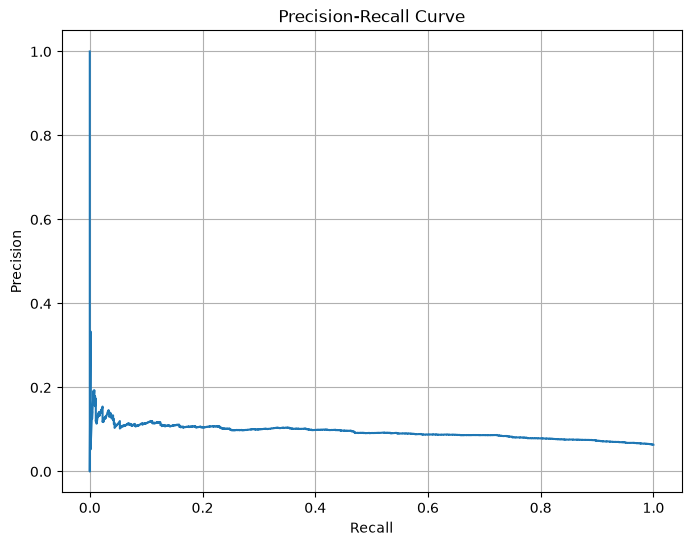

In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

pr_auc = average_precision_score(y_test, y_test_prob)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

## 5. Random Forest for Model Comparison
A Random Forest classifier was evaluated as a nonlinear alternative
to logistic regression. Both models were evaluated using the same
train/test split

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [138]:
X_encoded = pd.get_dummies(
    X,
    columns=["fuel_type", "region_density"],
    drop_first=True
)

In [139]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [140]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [141]:
y_test_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

In [142]:
rf_auc = roc_auc_score(y_test_rf, y_test_prob_rf)

print("Logistic Regression Test ROC-AUC:", test_auc)
print("Random Forest Test ROC-AUC:", rf_auc)

Logistic Regression Test ROC-AUC: 0.6242051843072902
Random Forest Test ROC-AUC: 0.5745847388093719


Logistic regression was more discrimanitory without the random forect, it was not improved by random forest test

In [143]:
X_encoded = pd.get_dummies(
    X,
    columns=["fuel_type", "region_density"],
    drop_first=True
)

In [144]:
import numpy as np

np.exp(0.0828)

np.float64(1.0863245219159159)

In [145]:
odds_ratios = np.exp(model2_train.params)

print(odds_ratios)

Intercept                     0.030113
C(fuel_type)[T.Diesel]        1.031813
C(fuel_type)[T.Petrol]        1.055056
C(region_density)[T.3264]     1.509861
C(region_density)[T.4076]     1.579095
C(region_density)[T.4990]     1.155481
C(region_density)[T.5410]     1.202114
C(region_density)[T.6108]     1.127419
C(region_density)[T.6112]     1.136643
C(region_density)[T.7788]     1.529532
C(region_density)[T.8794]     1.399910
C(region_density)[T.13051]    1.329623
C(region_density)[T.16206]    1.441624
C(region_density)[T.16733]    1.464293
C(region_density)[T.17804]    1.017232
C(region_density)[T.20905]    1.262473
C(region_density)[T.21622]    1.645244
C(region_density)[T.27003]    1.443163
C(region_density)[T.27742]    1.429810
C(region_density)[T.34738]    1.275239
C(region_density)[T.34791]    1.158590
C(region_density)[T.35036]    2.434883
C(region_density)[T.65567]    0.967422
C(region_density)[T.73430]    1.074153
customer_age                  1.004429
vehicle_age              

In [146]:
odds_ratio_table = pd.DataFrame({
    "Coefficient": model2_train.params,
    "Odds Ratio": np.exp(model2_train.params),
    "P-value": model2_train.pvalues
}).round(4)

print(odds_ratio_table)

                            Coefficient  Odds Ratio  P-value
Intercept                       -3.5028      0.0301   0.0000
C(fuel_type)[T.Diesel]           0.0313      1.0318   0.5523
C(fuel_type)[T.Petrol]           0.0536      1.0551   0.2907
C(region_density)[T.3264]        0.4120      1.5099   0.1745
C(region_density)[T.4076]        0.4569      1.5791   0.0288
C(region_density)[T.4990]        0.1445      1.1555   0.5482
C(region_density)[T.5410]        0.1841      1.2021   0.3971
C(region_density)[T.6108]        0.1199      1.1274   0.6218
C(region_density)[T.6112]        0.1281      1.1366   0.5751
C(region_density)[T.7788]        0.4250      1.5295   0.0460
C(region_density)[T.8794]        0.3364      1.3999   0.1012
C(region_density)[T.13051]       0.2849      1.3296   0.2614
C(region_density)[T.16206]       0.3658      1.4416   0.2281
C(region_density)[T.16733]       0.3814      1.4643   0.3069
C(region_density)[T.17804]       0.0171      1.0172   0.9395
C(region_density)[T.2090

In [147]:
conf = model2_train.conf_int()

odds_ratio_table = pd.DataFrame({
    "Coefficient": model2_train.params,
    "Odds Ratio": np.exp(model2_train.params),
    "OR Lower 95%": np.exp(conf[0]),
    "OR Upper 95%": np.exp(conf[1]),
    "P-value": model2_train.pvalues
}).round(4)

print(odds_ratio_table)

                            Coefficient  Odds Ratio  OR Lower 95%  \
Intercept                       -3.5028      0.0301        0.0190   
C(fuel_type)[T.Diesel]           0.0313      1.0318        0.9306   
C(fuel_type)[T.Petrol]           0.0536      1.0551        0.9552   
C(region_density)[T.3264]        0.4120      1.5099        0.8330   
C(region_density)[T.4076]        0.4569      1.5791        1.0484   
C(region_density)[T.4990]        0.1445      1.1555        0.7210   
C(region_density)[T.5410]        0.1841      1.2021        0.7850   
C(region_density)[T.6108]        0.1199      1.1274        0.7001   
C(region_density)[T.6112]        0.1281      1.1366        0.7263   
C(region_density)[T.7788]        0.4250      1.5295        1.0076   
C(region_density)[T.8794]        0.3364      1.3999        0.9362   
C(region_density)[T.13051]       0.2849      1.3296        0.8087   
C(region_density)[T.16206]       0.3658      1.4416        0.7953   
C(region_density)[T.16733]       0

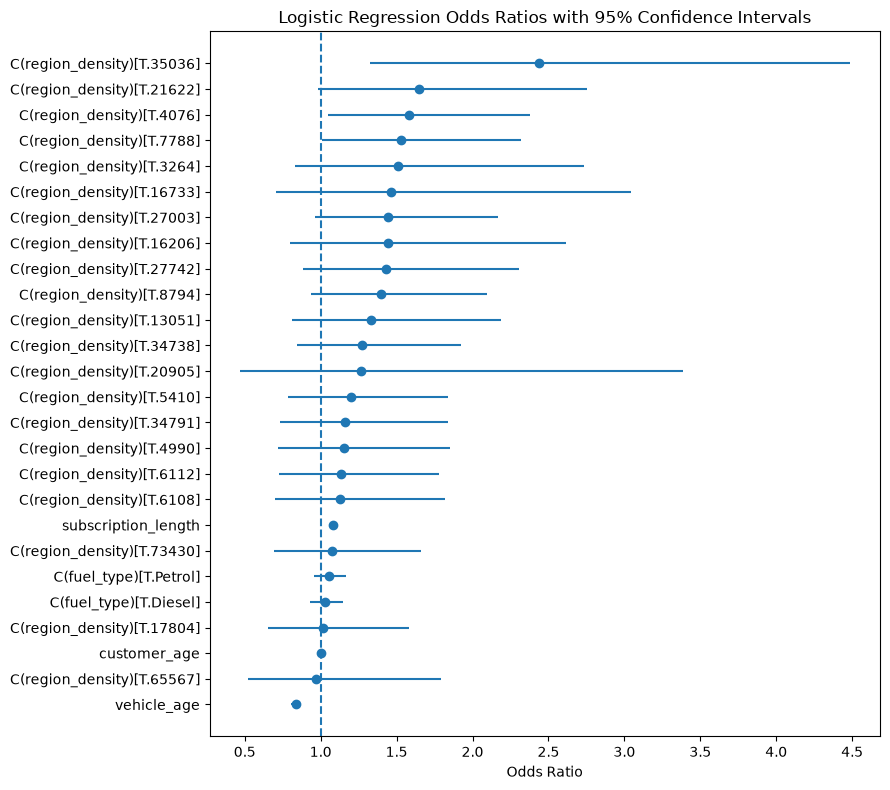

In [181]:
import matplotlib.pyplot as plt

plot_data = odds_ratio_table.drop("Intercept").copy()

plot_data = plot_data.sort_values("Odds Ratio")

plt.figure(figsize=(9, 8))

plt.errorbar(
    plot_data["Odds Ratio"],
    range(len(plot_data)),
    xerr=[
        plot_data["Odds Ratio"] - plot_data["OR Lower 95%"],
        plot_data["OR Upper 95%"] - plot_data["Odds Ratio"]
    ],
    fmt="o"
)

plt.axvline(1, linestyle="--")

plt.yticks(range(len(plot_data)), plot_data.index)
plt.xlabel("Odds Ratio")
plt.title("Logistic Regression Odds Ratios with 95% Confidence Intervals")
plt.tight_layout()
plt.savefig(
    "results/figures/odds_ratios.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [149]:
y_test_prob
print("Minimum predicted probability:", y_test_prob.min())
print("Maximum predicted probability:", y_test_prob.max())
print("Mean predicted probability:", y_test_prob.mean())
print("Actual claim rate:", y_test.mean())

Minimum predicted probability: 0.003032455457221124
Maximum predicted probability: 0.1725775511151076
Mean predicted probability: 0.06381969181298944
Actual claim rate: 0.06399863469579316


### Calibration

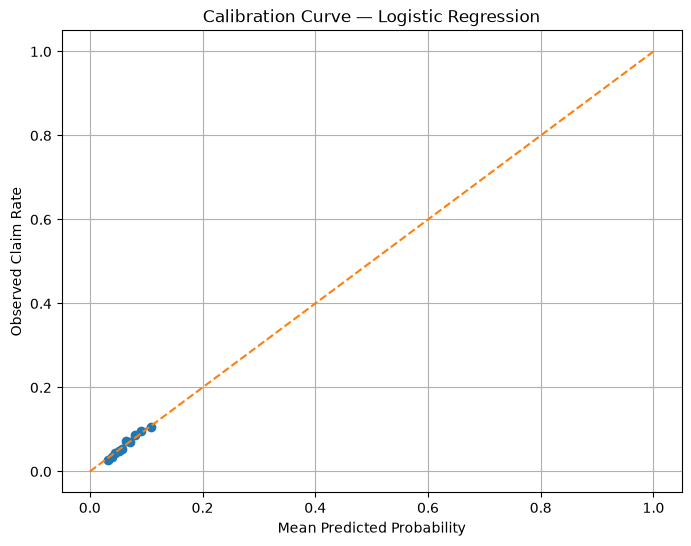

In [182]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Claim Rate")
plt.title("Calibration Curve — Logistic Regression")
plt.grid()

plt.savefig(
    "results/figures/calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The logistic regression demonstrated reasonable calibration on the held-out test set, with predicted probabilities closely tracking observed claim rates across probability bins.

## Key Findings
- Subscription length showed a strong positive association with claim
  status, with claim rates increasing across most subscription groups.

- Vehicle age showed a negative association with claim status in the
  multivariable logistic regression.

- Customer age showed differences in claim rates during exploratory
  analysis, but was not statistically significant after multivariable
  adjustment.

- Logistic regression achieved a test ROC-AUC of 0.6242, compared with
  0.5746 for the Random Forest on the same test set.

- The logistic regression showed reasonable calibration on the held-out
  test data.

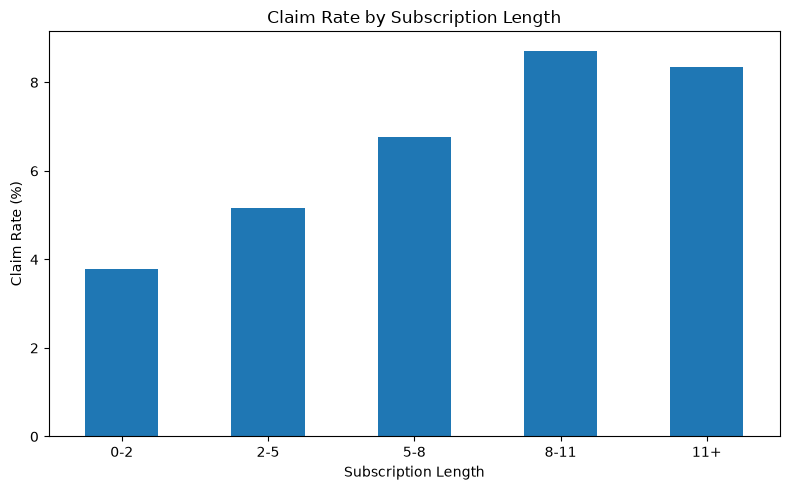

In [151]:
subscription_analysis["claim_rate"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Claim Rate by Subscription Length",
    xlabel="Subscription Length",
    ylabel="Claim Rate (%)"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

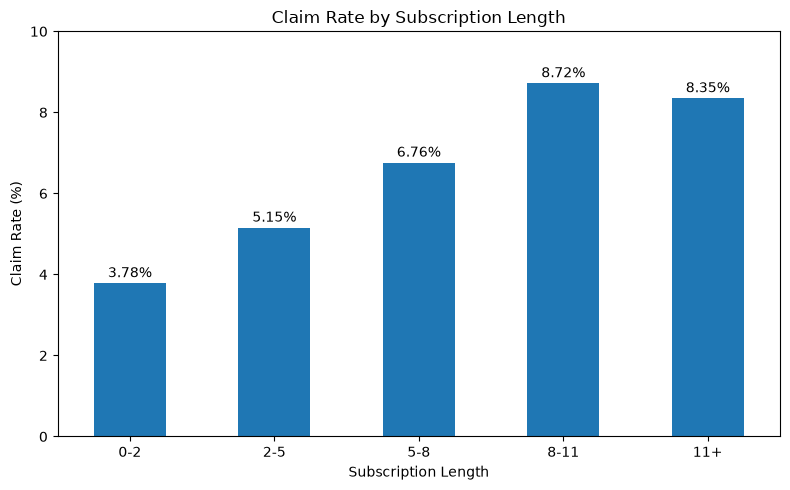

In [178]:
plt.figure(figsize=(8, 5))

ax = subscription_analysis["claim_rate"].plot(
    kind="bar"
)

plt.title("Claim Rate by Subscription Length")
plt.xlabel("Subscription Length")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=0)

# Add percentage labels
for i, value in enumerate(subscription_analysis["claim_rate"]):
    ax.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 10)
plt.tight_layout()
plt.savefig(
    "results/figures/claim_rate_subscription.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

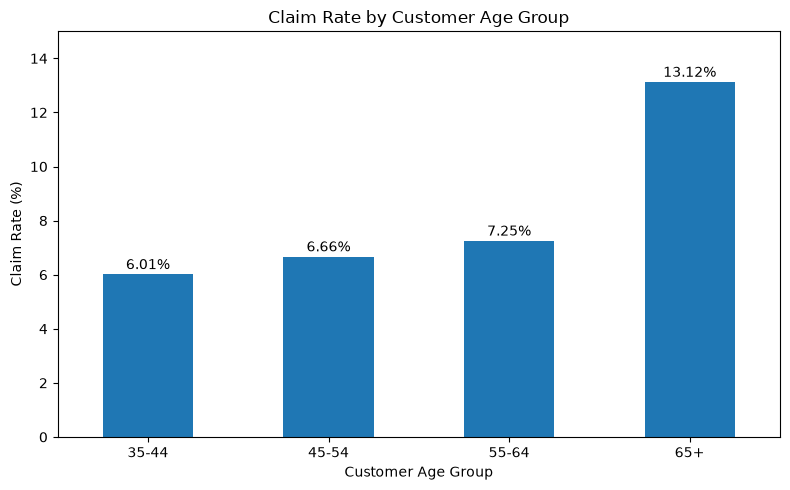

In [153]:
plt.figure(figsize=(8, 5))

ax = age_claim_analysis["claim_rate"].plot(
    kind="bar"
)

plt.title("Claim Rate by Customer Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=0)

# Add percentage labels
for i, value in enumerate(age_claim_analysis["claim_rate"]):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 15)
plt.tight_layout()
plt.show()

In [156]:
df["vehicle_age_group"] = pd.cut(
    df["vehicle_age"],
    bins=[-0.01, 1, 3, 5, float("inf")],
    labels=["0-1", "1-3", "3-5", "5+"]
)

In [157]:
df["vehicle_age_group"].value_counts().sort_index()

vehicle_age_group
0-1    28328
1-3    25815
3-5     4226
5+       223
Name: count, dtype: int64

In [158]:
vehicle_age_analysis = (
    df.groupby("vehicle_age_group", observed=True)
      .agg(
          observations=("claim_status", "size"),
          claims=("claim_status", "sum"),
          claim_rate=("claim_status", "mean")
      )
)

vehicle_age_analysis["claim_rate"] *= 100

vehicle_age_analysis

,observations,claims,claim_rate
vehicle_age_group,,,
0-1,28328,1913,6.753036
1-3,25815,1638,6.345148
3-5,4226,190,4.495977
5+,223,7,3.139013


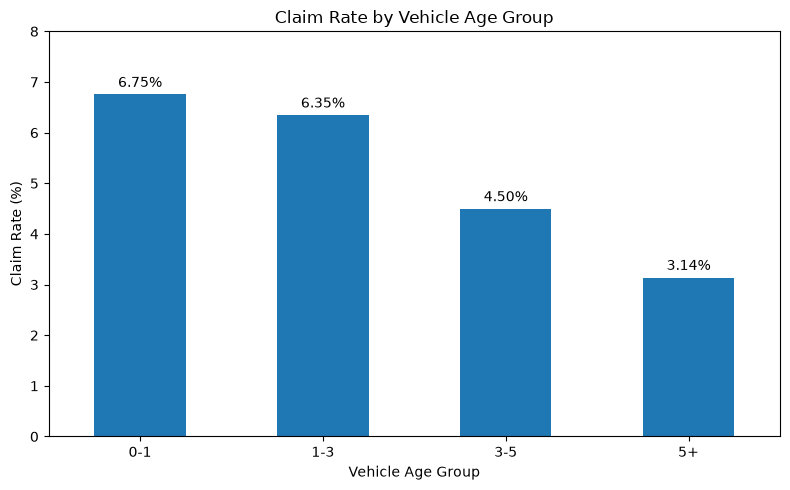

In [159]:
plt.figure(figsize=(8, 5))

ax = vehicle_age_analysis["claim_rate"].plot(
    kind="bar"
)

plt.title("Claim Rate by Vehicle Age Group")
plt.xlabel("Vehicle Age Group")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(vehicle_age_analysis["claim_rate"]):
    ax.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 8)
plt.tight_layout()
plt.show()

In [160]:
import os

os.makedirs("results", exist_ok=True)

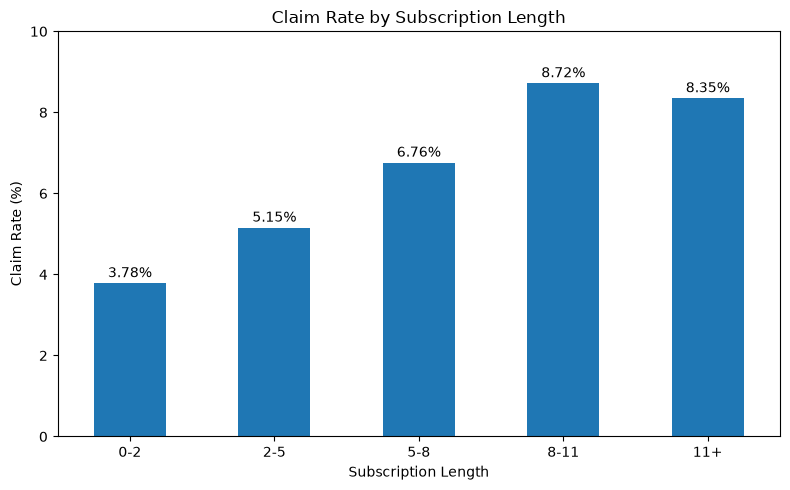

In [161]:
plt.figure(figsize=(8, 5))

ax = subscription_analysis["claim_rate"].plot(
    kind="bar"
)

plt.title("Claim Rate by Subscription Length")
plt.xlabel("Subscription Length")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(subscription_analysis["claim_rate"]):
    ax.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 10)
plt.tight_layout()

plt.savefig("results/claim_rate_subscription.png", dpi=300, bbox_inches="tight")

plt.show()

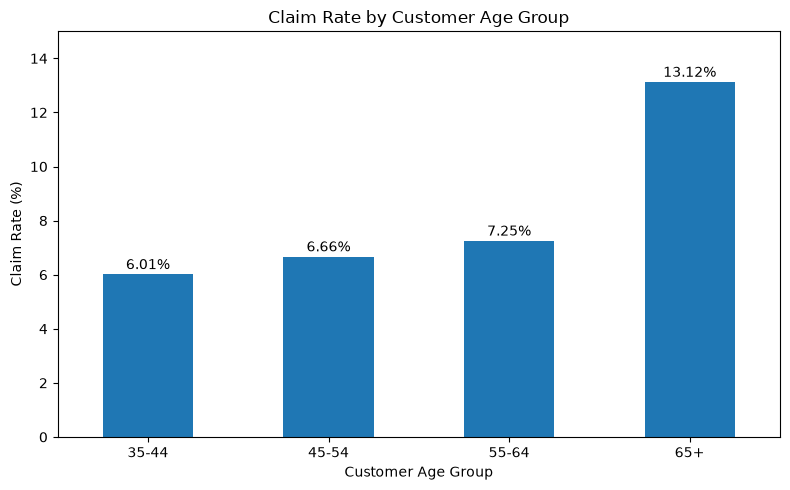

In [179]:
plt.figure(figsize=(8, 5))

ax = age_claim_analysis["claim_rate"].plot(
    kind="bar"
)

plt.title("Claim Rate by Customer Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(age_claim_analysis["claim_rate"]):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 15)
plt.tight_layout()

plt.savefig(
    "results/figures/claim_rate_customer_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

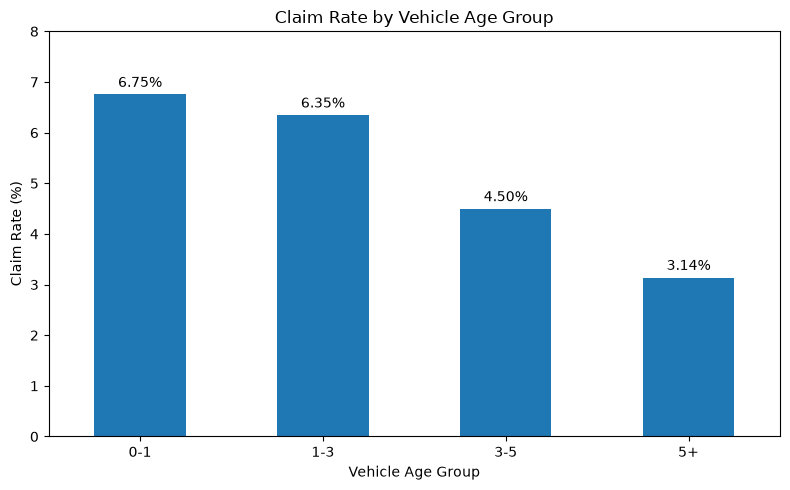

In [180]:
plt.figure(figsize=(8, 5))

ax = vehicle_age_analysis["claim_rate"].plot(
    kind="bar"
)

plt.title("Claim Rate by Vehicle Age Group")
plt.xlabel("Vehicle Age Group")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(vehicle_age_analysis["claim_rate"]):
    ax.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 8)
plt.tight_layout()

plt.savefig(
    "results/figures/claim_rate_vehicle_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [164]:
plt.savefig("results/odds_ratios.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [165]:
plt.savefig("results/calibration_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [166]:
os.listdir("results")

['calibration_curve.png',
 'odds_ratios.png',
 'claim_rate_customer_age.png',
 'claim_rate_subscription.png',
 'claim_rate_vehicle_age.png']

In [167]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Test ROC-AUC": [
        test_auc,
        rf_auc
    ]
})

model_comparison

,Model,Test ROC-AUC
0,Logistic Regression,0.624205
1,Random Forest,0.574585


In [168]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Test ROC-AUC": [
        test_auc,
        rf_auc
    ]
})

model_comparison

,Model,Test ROC-AUC
0,Logistic Regression,0.624205
1,Random Forest,0.574585


### Model Comparison

Both models were evaluated on the same held-out test set. Logistic
regression achieved a test ROC-AUC of 0.6242, while the Random Forest
achieved 0.5746. In this dataset and evaluation setup, logistic
regression provided stronger discrimination between customers whohave and don't have a claim.

## Conclusion 

This analysis explored factors associated with insurance claim status using
58,592 observations. Exploratory analysis and chi-square tests identified
statistically significant associations between claim status and customer
age group, vehicle age group, subscription length, and region density.

A logistic regression model was then developed using customer age, vehicle
age, subscription length, fuel type, and region density. Subscription length
and vehicle age were particularly important predictors in the fitted model.
Holding the other modeled variables constant, each additional unit of
subscription length was associated with approximately 8.3% higher claim
odds, while each additional year of vehicle age was associated with
approximately 16.4% lower claim odds. These results describe associations
in the dataset and should not be interpreted as causal effects.

The logistic regression achieved a ROC-AUC of 0.624 on the held-out test
set, compared with 0.575 for the Random Forest model. The logistic model
therefore provided stronger discrimination in this evaluation. Its
predicted probabilities also showed reasonable calibration on the test
set.

Overall, the analysis demonstrates how exploratory analysis, statistical
testing, regression modeling, and model evaluation can be combined to
investigate insurance claim risk. The model has limited predictive power,
however, indicating that additional variables or alternative modeling
approaches could be needed for a stronger risk prediction system.

In [175]:
import os
os.makedirs("results/figures", exist_ok=True)

In [176]:
plt.savefig(
    "results/figures/claim_rate_subscription.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

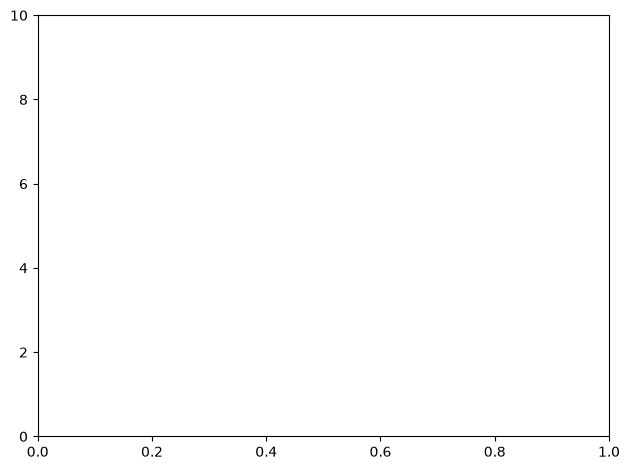

In [177]:
plt.ylim(0, 10)
plt.tight_layout()

plt.savefig(
    "results/figures/claim_rate_subscription.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()